**TRABALHO BIMESTRAL - APRENDIZADO DE MÁQUINAS - ALGORITMO DE CLASSIFICAÇÃO - DATASET "Violence Against Women & Girls"**


---

## Carregando os dados

In [71]:
from google.colab import drive
drive.mount('/content/drive')

# importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.plotting import scatter_matrix

#importando o arquivo
df = pd.read_csv('/content/drive/My Drive/FATEC/DSM5/aprendizado/girlsviolence.csv', sep=',')
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,RecordID,Country,Gender,Demographics Question,Demographics Response,Question,Survey Year,Value
0,1,Afghanistan,F,Marital status,Never married,... if she burns the food,01/01/2015,NaN
1,1,Afghanistan,F,Education,Higher,... if she burns the food,01/01/2015,10.1
2,1,Afghanistan,F,Education,Secondary,... if she burns the food,01/01/2015,13.7
3,1,Afghanistan,F,Education,Primary,... if she burns the food,01/01/2015,13.8
4,1,Afghanistan,F,Marital status,"Widowed, divorced, separated",... if she burns the food,01/01/2015,13.8


## Pré-processamento: eliminação de atributos irrelevantes

In [72]:
# remove as colunas Survey Year e RecordID
df = df.drop(columns=['Survey Year','RecordID'])

# imprime o dataframe
display(df.head(n=10))

,Country,Gender,Demographics Question,Demographics Response,Question,Value
0,Afghanistan,F,Marital status,Never married,... if she burns the food,NaN
1,Afghanistan,F,Education,Higher,... if she burns the food,10.1
2,Afghanistan,F,Education,Secondary,... if she burns the food,13.7
3,Afghanistan,F,Education,Primary,... if she burns the food,13.8
4,Afghanistan,F,Marital status,"Widowed, divorced, separated",... if she burns the food,13.8
5,Afghanistan,F,Employment,Employed for kind,... if she burns the food,17.0
6,Afghanistan,F,Age,15-24,... if she burns the food,17.3
7,Afghanistan,F,Employment,Unemployed,... if she burns the food,18.0
8,Afghanistan,F,Residence,Rural,... if she burns the food,18.1
9,Afghanistan,F,Age,25-34,... if she burns the food,18.2


***Removi as colunas RecordID e Survey Year pois são irrelevantes para a tarefa de classificação que necessito***

## Pré-processamento: tratamento de atributos com valores ausentes

In [73]:
# índices das linhas que contém valores NaN
idxRowNan = pd.isnull(df).any(axis=1).to_numpy().nonzero()

# imprime apenas as linhas com valoes ausentes
display(df.iloc[idxRowNan])

,Country,Gender,Demographics Question,Demographics Response,Question,Value
0,Afghanistan,F,Marital status,Never married,... if she burns the food,NaN
15,Afghanistan,M,Marital status,Never married,... if she burns the food,NaN
81,Afghanistan,F,Marital status,Never married,... for at least one specific reason,NaN
84,Afghanistan,F,Marital status,Never married,... if she argues with him,NaN
87,Afghanistan,F,Marital status,Never married,... if she goes out without telling him,NaN
...,...,...,...,...,...,...
12235,Yemen,M,Residence,Urban,... if she goes out without telling him,NaN
12236,Yemen,M,Residence,Rural,... if she neglects the children,NaN
12237,Yemen,M,Residence,Urban,... if she neglects the children,NaN
12238,Yemen,M,Residence,Rural,... if she refuses to have sex with him,NaN


In [74]:
import pandas as pd

def trataFaltantes(df):

    # linhas sem NaN
    notNull = df.loc[~pd.isnull(df['Value']), :]

    # percorre cada país
    for pais in df['Country'].unique():

        # calcula média do país
        media = notNull[
            notNull['Country'] == pais
        ]['Value'].mean()

        # substitui os NaN daquele país
        df.loc[
            (pd.isnull(df['Value'])) &
            (df['Country'] == pais),
            'Value'
        ] = media

    return df


trataFaltantes(df)

# imprime apenas as linhas que antes possuiam valores NaN
print('\nAmostras que possuiam valores faltantes:')
display(df.iloc[idxRowNan])


Amostras que possuiam valores faltantes:


,Country,Gender,Demographics Question,Demographics Response,Question,Value
0,Afghanistan,F,Marital status,Never married,... if she burns the food,42.683333
15,Afghanistan,M,Marital status,Never married,... if she burns the food,42.683333
81,Afghanistan,F,Marital status,Never married,... for at least one specific reason,42.683333
84,Afghanistan,F,Marital status,Never married,... if she argues with him,42.683333
87,Afghanistan,F,Marital status,Never married,... if she goes out without telling him,42.683333
...,...,...,...,...,...,...
12235,Yemen,M,Residence,Urban,... if she goes out without telling him,27.621111
12236,Yemen,M,Residence,Rural,... if she neglects the children,27.621111
12237,Yemen,M,Residence,Urban,... if she neglects the children,27.621111
12238,Yemen,M,Residence,Rural,... if she refuses to have sex with him,27.621111


tratei os valores ausente por país

## Pré-processamento: tratamento de dados inconsistentes ou redundantes

dados duplicados são "relevantes", ou seja, não são inconsistências e são parte importante do estudo e para o resultado do aprendizado

In [75]:
# para detectar inconsistências, a rotina abaixo obtém as amostras onde os valores
# dos atributos continuam duplicados. Neste caso, os atributos serão iguais, mas as classes serão distintas
df_duplicates = df[ df.duplicated(subset=['Country','Gender','Demographics Question','Demographics Response','Question','Value'],keep=False)]

# se tiver valores inconsistentes, imprime
if len(df_duplicates)>0:
   print('\nAmostras inconsistentes:')
   display(df_duplicates)
else:
   print('Não existem mostras inconsistentes')


Não existem mostras inconsistentes


In [76]:
# apresenta as principais estatísticas da base de dados
df_detalhes = df.describe()

display(df_detalhes)


,Value
count,12600.000000
mean,19.906060
std,16.839744
min,0.000000
25%,6.500000
50%,14.719048
75%,29.700000
max,86.900000


In [77]:
df[df['Value'] > 80]

,Country,Gender,Demographics Question,Demographics Response,Question,Value
30,Afghanistan,F,Age,15-24,... for at least one specific reason,80.1
31,Afghanistan,F,Age,25-34,... for at least one specific reason,81.5
46,Afghanistan,F,Education,No education,... for at least one specific reason,81.0
65,Afghanistan,F,Employment,Employed for cash,... for at least one specific reason,80.2
66,Afghanistan,F,Employment,Employed for kind,... for at least one specific reason,86.9
67,Afghanistan,F,Employment,Unemployed,... for at least one specific reason,80.1
80,Afghanistan,F,Marital status,Married or living together,... for at least one specific reason,80.6
95,Afghanistan,F,Residence,Rural,... for at least one specific reason,82.1
3666,Eritrea,F,Employment,Employed for kind,... for at least one specific reason,82.8
7381,Mali,F,Age,25-34,... for at least one specific reason,81.4


## Pré-processamento: detecção de *outliers*

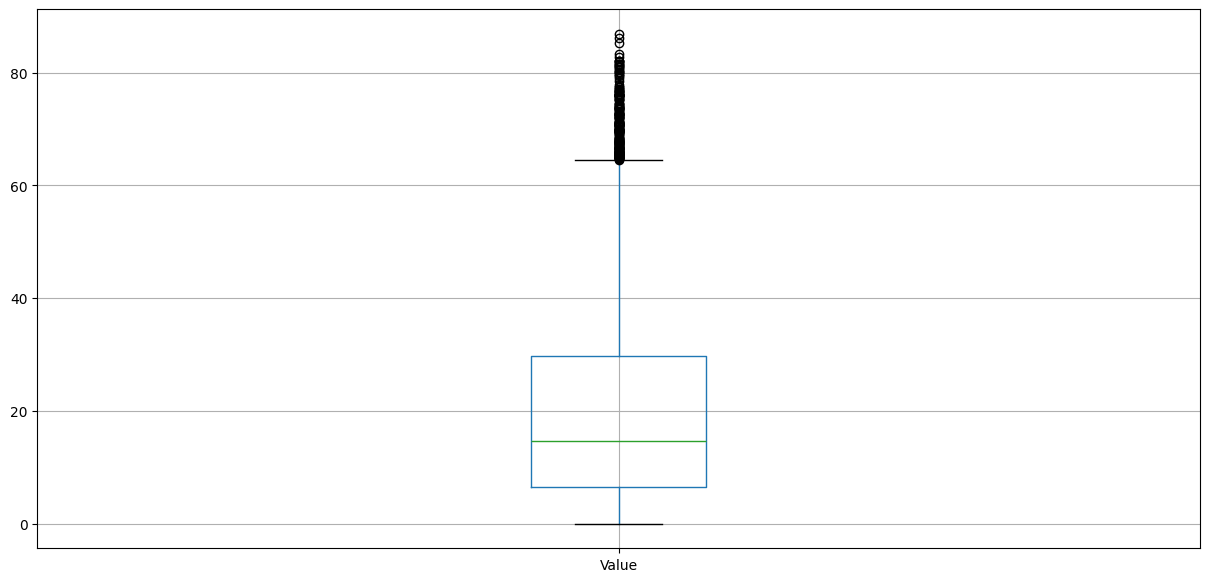

In [78]:
# gera um bloxplot para cada atributo
df.boxplot(figsize=(15,7))
plt.show()


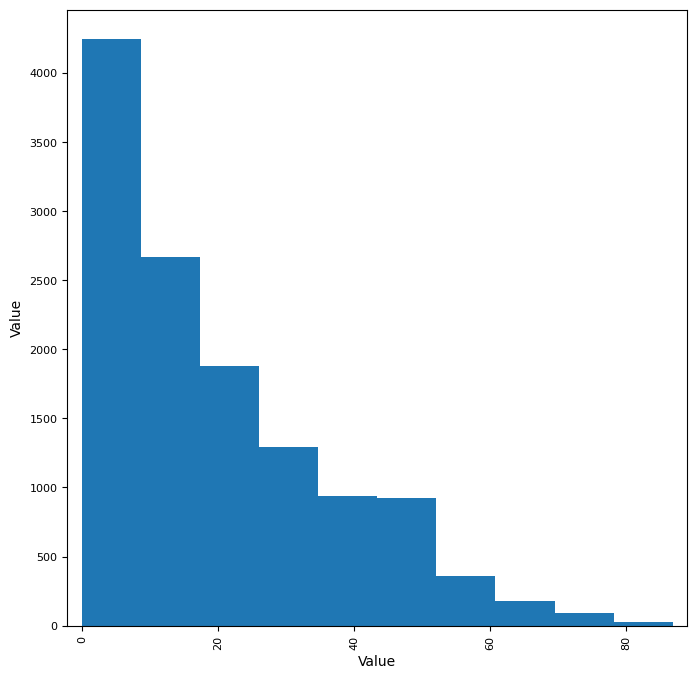

In [79]:
pd.plotting.scatter_matrix(df, figsize=(8,8))
plt.show()


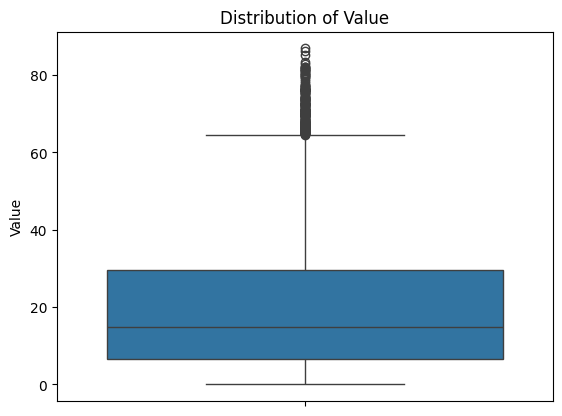

count    12600.000000
mean        19.906060
std         16.839744
min          0.000000
25%          6.500000
50%         14.719048
75%         29.700000
max         86.900000
Name: Value, dtype: float64


In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of the 'Value' column using a boxplot
sns.boxplot(y='Value', data=df)

# Add a title to the plot
plt.title('Distribution of Value')

# Show the plot
plt.show()

print(df['Value'].describe())



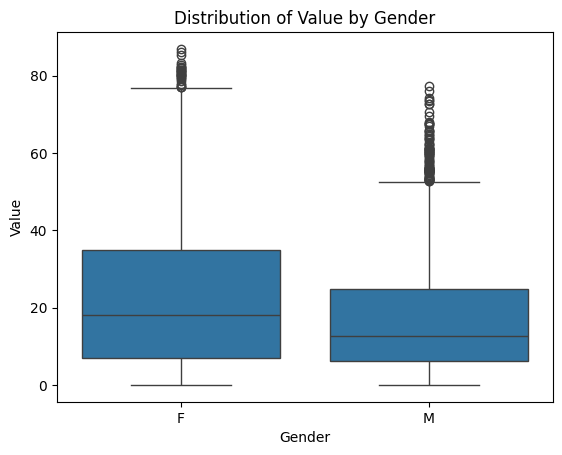

In [81]:
# Create a boxplot to visualize 'Value' across different genders
sns.boxplot(x='Gender', y='Value', data=df)

# Create a title for the plot
plt.title('Distribution of Value by Gender')

# Show the plot
plt.show()

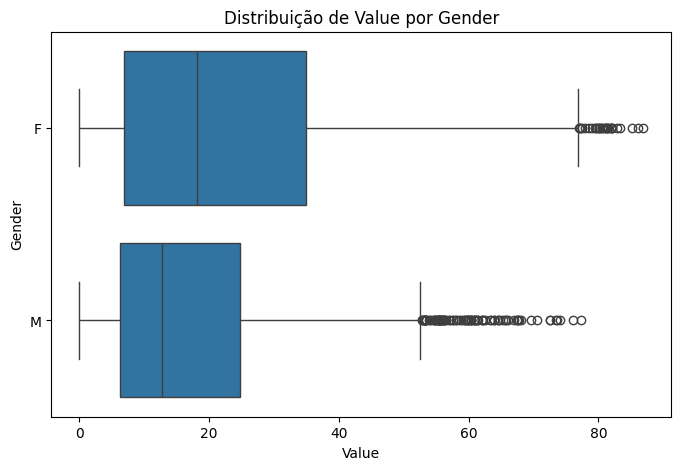

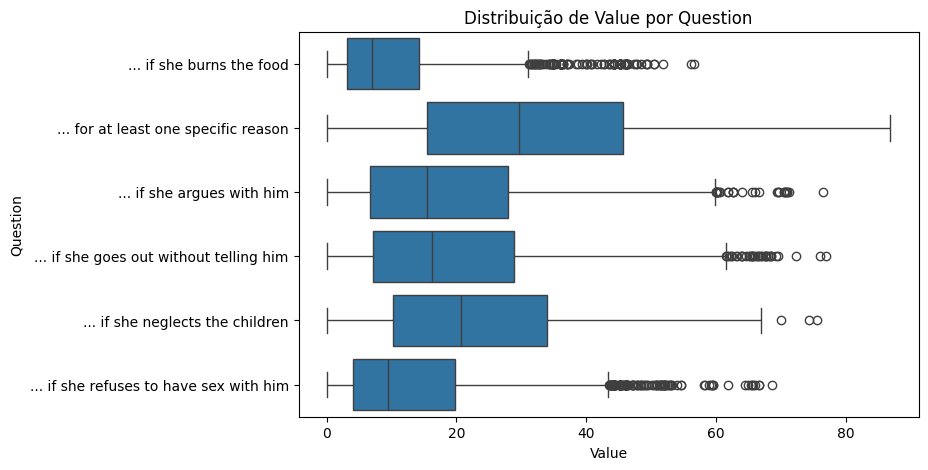

In [82]:
# Análise da distribuição de Value em atributos importantes

atributos = [
    'Gender',
    'Question'
]

for atributo in atributos:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        x='Value',
        y=atributo,
        data=df
    )

    plt.title(f'Distribuição de Value por {atributo}')

    plt.show()


escolhi nao remover os outliers pois eles não são tão extremos e dado as caracteristicas demograficas e de genero do país é altamente provavel a ressposta estar correta.

## Pré-processamento: distribuição das classes

In [83]:
print(df['Value'].describe())

count    12600.000000
mean        19.906060
std         16.839744
min          0.000000
25%          6.500000
50%         14.719048
75%         29.700000
max         86.900000
Name: Value, dtype: float64


In [84]:
# importando todas as bibliotecas importantes para cálculo e criação de visualização gráfica
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px
from pandas.plotting import scatter_matrix
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC



In [85]:
# Dimensão
print(df.shape)

(12600, 6)


In [86]:
# Resumo estatístico
print(df.describe())

              Value
count  12600.000000
mean      19.906060
std       16.839744
min        0.000000
25%        6.500000
50%       14.719048
75%       29.700000
max       86.900000


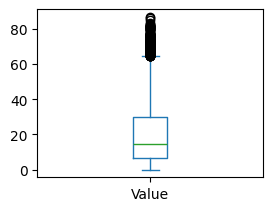

In [87]:
# gráfico de box and whisker
df.plot(kind='box', subplots=True, layout=(2,2), sharex=False, sharey=False)
plt.show()

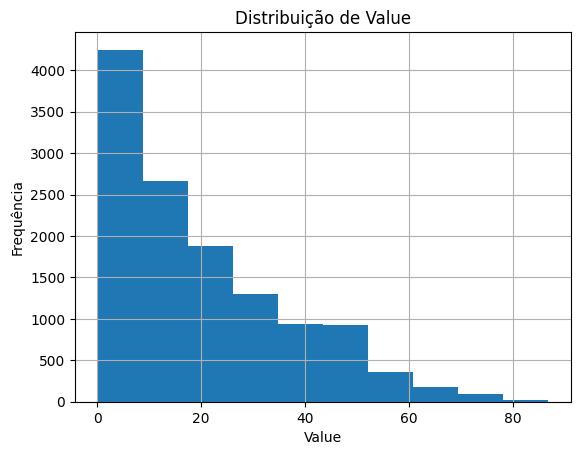

,count
Classe,
Baixa,3159
Alta,3151
Muito_Alta,3147
Media,3143


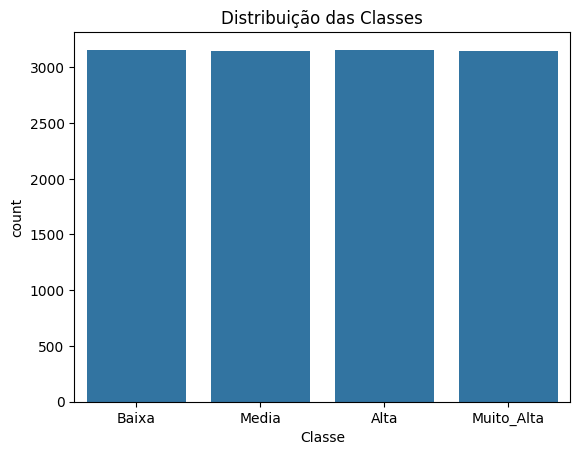

In [88]:
# Histograma ANTES de remover Value
df['Value'].hist()

plt.title('Distribuição de Value')
plt.xlabel('Value')
plt.ylabel('Frequência')
plt.show()

# Criar a classe
df['Classe'] = pd.qcut(
    df['Value'],
    q=4,
    labels=['Baixa', 'Media', 'Alta', 'Muito_Alta']
)

# Verificar as classes
display(df['Classe'].value_counts())

sns.countplot(x='Classe', data=df)
plt.title('Distribuição das Classes')
plt.show()



##Criar conjunto de validação

In [90]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Make a copy to avoid modifying the original dataframe directly during encoding
df_processed = df.copy()

# Identify categorical features and target
categorical_features_X = ['Country', 'Gender', 'Demographics Question', 'Demographics Response', 'Question']
target_feature_Y = 'Classe'

# Apply LabelEncoder to the target variable 'Classe'
le = LabelEncoder()
df_processed[target_feature_Y + '_encoded'] = le.fit_transform(df_processed[target_feature_Y])
Y = df_processed[target_feature_Y + '_encoded'].values

# Apply OneHotEncoder to the categorical features in X
# Create a ColumnTransformer to apply OneHotEncoder to specific columns
ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'), categorical_features_X)
    ],
    remainder='passthrough' # Keep other columns if any, but in this case X only has these 4
)

# Apply the ColumnTransformer to create X
X = ct.fit_transform(df_processed[categorical_features_X]).toarray() # .toarray() converts sparse matrix to dense array

validation_size = 0.20
seed = 7
X_train, X_validation, Y_train, Y_validation = model_selection.train_test_split(X, Y, test_size=validation_size, random_state=seed)

print(X_train.shape)
print(Y_train.shape)

print(X_validation.shape)
print(Y_validation.shape)


(10080, 98)
(10080,)
(2520, 98)
(2520,)


In [91]:
# Métricas
seed = 7
scoring = 'accuracy'

### Regressão Logística (LR)
### Análise Linear Discriminante (LDA)
### K-vizinhos mais próximos (KNN)
### Árvores de Classificação (Decision Tree) e Regressão (CART)
### Gaussian Naive Bayes (NB)
### Support Vector Machines (SVM)

In [92]:
# Algoritmos
models = []
models.append(('LR', LogisticRegression(solver='liblinear')))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(gamma='auto')))

# Avaliação de cada modelo
results = []
names = []
for name, model in models:
   kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=seed)
   cv_results = model_selection.cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
   results.append(cv_results)
   names.append(name)
   msg = '%s: %f (%f)' % (name, cv_results.mean(), cv_results.std())
   print(msg)

LR: 0.677083 (0.015138)
LDA: 0.671230 (0.018417)
KNN: 0.370139 (0.014610)
CART: 0.772917 (0.011024)
NB: 0.454762 (0.015293)
SVM: 0.617163 (0.018295)


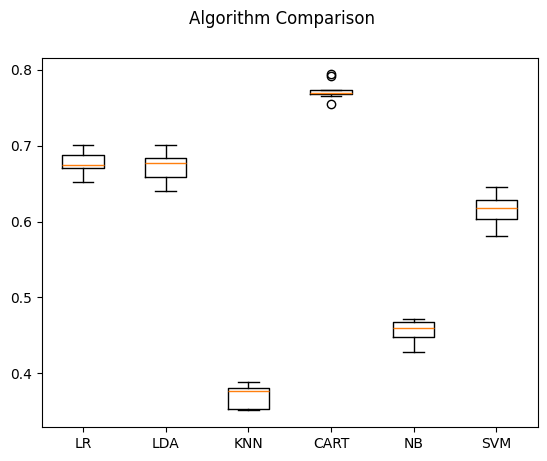

In [93]:
# Comparação dos Algoritmos
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

ESCOLHA DO MELHOR ALGORITMO - ALGORITMO DE ÁRVORE DE DECISÃO 'Regressão (CART)'

In [96]:
cart = DecisionTreeClassifier(random_state=seed)

cart.fit(X_train, Y_train)

predictions = cart.predict(X_validation)

print("Accuracy:", accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

Accuracy: 0.7908730158730158
[[461  13  84  77]
 [  4 498  93   0]
 [ 71  97 450   2]
 [ 79   3   4 584]]
              precision    recall  f1-score   support

           0       0.75      0.73      0.74       635
           1       0.82      0.84      0.83       595
           2       0.71      0.73      0.72       620
           3       0.88      0.87      0.88       670

    accuracy                           0.79      2520
   macro avg       0.79      0.79      0.79      2520
weighted avg       0.79      0.79      0.79      2520



In [97]:
# Precisão do melhor modelo no conjunto de validação

cart = DecisionTreeClassifier(random_state=seed)

cart.fit(X_train, Y_train)

predictions = cart.predict(X_validation)

print("Accuracy:", accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

Accuracy: 0.7908730158730158
[[461  13  84  77]
 [  4 498  93   0]
 [ 71  97 450   2]
 [ 79   3   4 584]]
              precision    recall  f1-score   support

           0       0.75      0.73      0.74       635
           1       0.82      0.84      0.83       595
           2       0.71      0.73      0.72       620
           3       0.88      0.87      0.88       670

    accuracy                           0.79      2520
   macro avg       0.79      0.79      0.79      2520
weighted avg       0.79      0.79      0.79      2520



##Fazer treinamento e validação de todos os algoritmos.

In [101]:
algoritmos = [
    ('LR', LogisticRegression(solver='liblinear')),
    ('LDA', LinearDiscriminantAnalysis()),
    ('KNN', KNeighborsClassifier()),
    ('CART', DecisionTreeClassifier(random_state=seed)),
    ('NB', GaussianNB()),
    ('SVM', SVC(gamma='auto'))
]

for nome, modelo in algoritmos:

    print("\n" + "="*60)
    print(f"ALGORITMO: {nome}")
    print("="*60)

    modelo.fit(X_train, Y_train)

    predictions = modelo.predict(X_validation)

    print("Accuracy:")
    print(accuracy_score(Y_validation, predictions))

    print("\nMatriz de Confusão:")
    print(confusion_matrix(Y_validation, predictions))

    print("\nRelatório de Classificação:")
    print(classification_report(Y_validation, predictions))


ALGORITMO: LR
Accuracy:
0.6833333333333333

Matriz de Confusão:
[[372  23  87 153]
 [ 16 482  95   2]
 [131 165 302  22]
 [ 86   6  12 566]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.61      0.59      0.60       635
           1       0.71      0.81      0.76       595
           2       0.61      0.49      0.54       620
           3       0.76      0.84      0.80       670

    accuracy                           0.68      2520
   macro avg       0.67      0.68      0.68      2520
weighted avg       0.68      0.68      0.68      2520


ALGORITMO: LDA
Accuracy:
0.6734126984126985

Matriz de Confusão:
[[413   8 108 106]
 [ 23 424 148   0]
 [131  97 380  12]
 [181   1   8 480]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.55      0.65      0.60       635
           1       0.80      0.71      0.75       595
           2       0.59      0.61      0.60       620
     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy:
0.6384920634920634

Matriz de Confusão:
[[414  27 106  88]
 [ 39 408 137  11]
 [182  89 317  32]
 [145  19  36 470]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.53      0.65      0.59       635
           1       0.75      0.69      0.72       595
           2       0.53      0.51      0.52       620
           3       0.78      0.70      0.74       670

    accuracy                           0.64      2520
   macro avg       0.65      0.64      0.64      2520
weighted avg       0.65      0.64      0.64      2520



# **Comparando valores reais e previstos**

In [103]:

comparacao = pd.DataFrame({
    'Classe real': le.inverse_transform(Y_validation),
    'Classe prevista': le.inverse_transform(predictions)
})

display(comparacao.head(20))

,Classe real,Classe prevista
0,Muito_Alta,Alta
1,Alta,Alta
2,Baixa,Baixa
3,Alta,Alta
4,Baixa,Media
5,Muito_Alta,Alta
6,Media,Alta
7,Muito_Alta,Muito_Alta
8,Alta,Alta
9,Baixa,Baixa
